In [319]:
function EMpath(u0,T,N,d,m,fhandle,ghandle,kappa0, M; rng)
    #small step
    Dtref = T/N 
    #large step
    Dt = kappa0*Dtref
    #number of large steps
    NN = div(N,kappa0)
    
    #initialization of solution
    u = zeros(d,M,NN+1)
    #initializaion of time grid
    t = zeros(NN+1)
    #initialization of gdW
    gdW=zeros(d,M)

    #current u, start with u0
    u_n = copy(u0)

    for n in 1:NN
        t[n] = (n-1)*Dt
        u[:,:,n] = u_n
        
        #dW = sqrt(Dtref) .* dropdims(sum(randn(rng, m, M, kappa0); dims=3); dims=3)
        dW = zeros(Float64, m, M)
        for r in 1:kappa0
            dW .+= sqrt(Dtref) .* randn(rng, m, M)
        end


        for mm in 1:M
            gdW[:,mm] = ghandle(view(u_n, :, mm)) * dW[:, mm]
        end
        u_n .= u_n.+ Dt.*fhandle(u_n).+gdW
    end
    t[NN+1] = NN*Dt
    u[:,:,NN+1] .= u_n
    return t, u
end

EMpath (generic function with 1 method)

In [320]:
using Random
function runEMpath(u0,T,Nref,d,m,fhandle,ghandle,kappas,M)
    #S = 0.0 #counter for sum
    S = zeros(length(kappas))
    #block size
    Mstep = 1000 
    #indexing for the blocks
    m0 = 1
    
    #replicates the global stream best (I think) from reading documentation
    rng = MersenneTwister(69)
    
    for mm in 1:Mstep:M
        #num of samples in this block (not needed if M is a multiple of Mstep)
        MM = min(Mstep, M - mm + 1) 
        #initial values for MM samples
        u00 = u0[:, mm:m0+MM-1]

        savedState = copy(rng)
        rng = copy(savedState)
        #reference solution and time grid using EMpath function (Algorithm 8.5) 
        tref, uref = EMpath(u00, T, Nref, d, m, fhandle, ghandle, 1, MM; rng = rng)

        for (i,kappa) in pairs(kappas)
            rng = copy(savedState)
            #coarse solution and time grid using EMpath function (Algortithm 8.5)
            t, u = EMpath(u00, T, Nref, d, m, fhandle, ghandle, kappa, MM; rng = rng)
            
            #error at the last time slice 
            err = u[:, :, end] .- uref[:, :, end]

            #add the sum of the elementwise squared errors to the counter
            #S += sum(err .* err)
            S[i] += sum(err .* err)
        end
        #set new indexing for m0 since we are moving on to next block
        m0 += MM
    end

    #operations to get RMS 
    rmsErr = sqrt.(S ./ M) 

    return rmsErr
end
        
    

runEMpath (generic function with 1 method)

In [321]:
# parameters
T = 1.0
Nref = 2^12
d = 1
m = 1
M = 5000
####################
#Geometric Brownian motion Eq. (8.11) in Lord
r = 2.0
σ = 1.0

fhandle(u) = r .* u
ghandle(uvec) = reshape([σ * uvec[1]], 1, 1)
##########################

u0 = ones(d, M)

kappas = [2, 4, 8, 16, 32, 64, 128]

rmsErr = runEMpath(u0, T, Nref, d, m, fhandle, ghandle, kappas, M)

Δtref = T/Nref
dts = kappas .* Δtref

println("dt values:")
println(dts)

println("RMS errors:")
println(rmsErr)


dt values:
[0.00048828125, 0.0009765625, 0.001953125, 0.00390625, 0.0078125, 0.015625, 0.03125]
RMS errors:
[0.13171371785821756, 0.23880941638475567, 0.35102175824532467, 0.5180899642484382, 0.7692028679302129, 1.1584927360660566, 1.9260192516432297]


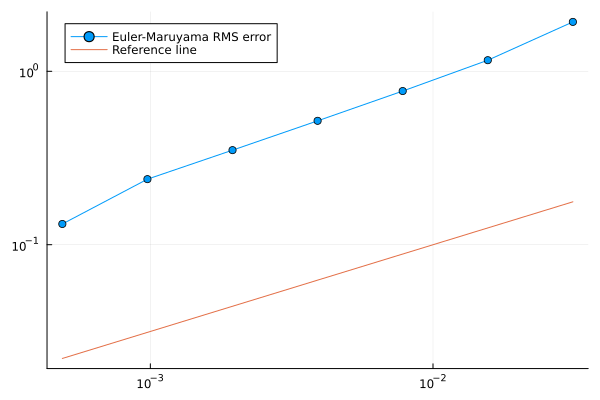

In [322]:
using Plots 
x = range(minimum(dts),maximum(dts),10)
# log-log plot
plot(dts, rmsErr, xaxis=:log, yaxis=:log, marker=:circle, label="Euler-Maruyama RMS error")
plot!(x,x.^0.5, xaxis=:log, yaxis=:log, label="Reference line")